# **Assignment 19: Text Classification and Sentiment Analysis (amazonreviews.tsv)**

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

**Task 1: Data Cleaning & Preprocessing**

In [9]:
# Load dataset
df_reviews = pd.read_csv("/content/amazonreviews.tsv", sep="\t")

print("--- Dataset Information ---")
print(df_reviews.info())

print("\n--- Missing Values Count ---")
print(df_reviews.isnull().sum())

# Remove duplicates if any[cite: 21]
df_clean = df_reviews.drop_duplicates().dropna().copy()

# Encode target label: 'pos' -> 1, 'neg' -> 0[cite: 21]
df_clean["target"] = (df_clean["label"] == "pos").astype(int)

print(
    f"\nCleaned Dataset Shape: {df_clean.shape} (Removed {len(df_reviews) - len(df_clean)} duplicates)"
)

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB
None

--- Missing Values Count ---
label     0
review    0
dtype: int64

Cleaned Dataset Shape: (10000, 3) (Removed 0 duplicates)


**Task 2: Exploratory Data Analysis (EDA**

/tmp/ipykernel_1582/3834227465.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="label", data=df_clean, palette="Set1")


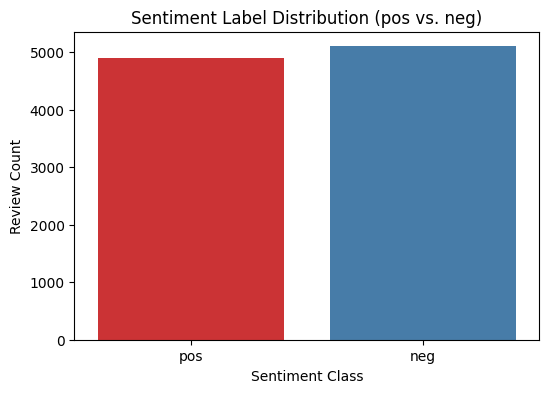

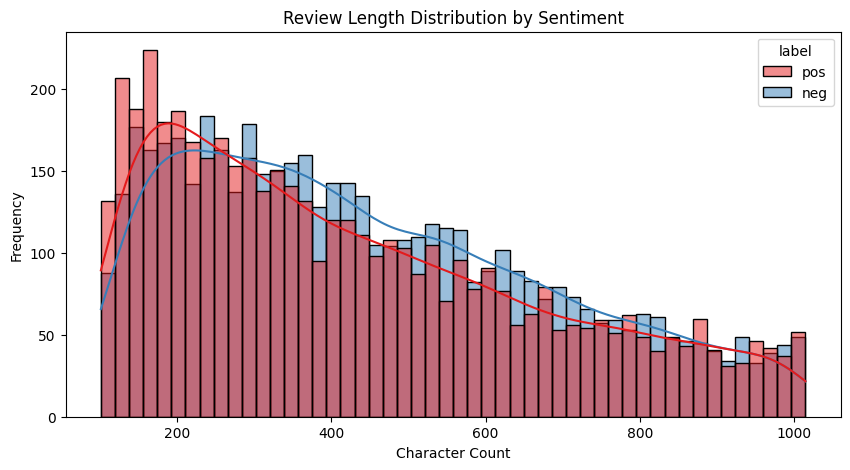

In [10]:
# Sentiment Class Distribution[cite: 21]
plt.figure(figsize=(6, 4))
sns.countplot(x="label", data=df_clean, palette="Set1")
plt.title("Sentiment Label Distribution (pos vs. neg)")
plt.xlabel("Sentiment Class")
plt.ylabel("Review Count")
plt.show()

# Review Length Distribution
df_clean["review_length"] = df_clean["review"].apply(len)

plt.figure(figsize=(10, 5))
sns.histplot(
    data=df_clean,
    x="review_length",
    hue="label",
    bins=50,
    kde=True,
    palette="Set1",
)
plt.title("Review Length Distribution by Sentiment")
plt.xlabel("Character Count")
plt.ylabel("Frequency")
plt.show()

**Task 3: Feature Extraction & Model Development**

In [11]:
# Train-Test Split (80% Train, 20% Test)[cite: 21]
X_train, X_test, y_train, y_test = train_test_split(
    df_clean["review"],
    df_clean["target"],
    test_size=0.2,
    random_state=42,
    stratify=df_clean["target"],
)

# TF-IDF Feature Extraction (Unigrams & Bigrams)[cite: 21]
tfidf = TfidfVectorizer(stop_words="english", max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("\n--- Feature Matrix Dimensions ---")
print("Train TF-IDF Matrix Shape:", X_train_tfidf.shape)
print("Test TF-IDF Matrix Shape :", X_test_tfidf.shape)

# 1. Logistic Regression Model[cite: 21]
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train_tfidf, y_train)
preds_lr = model_lr.predict(X_test_tfidf)

# 2. Linear Support Vector Machine (SVM)[cite: 21]
model_svm = LinearSVC(dual="auto", random_state=42)
model_svm.fit(X_train_tfidf, y_train)
preds_svm = model_svm.predict(X_test_tfidf)

# 3. Multinomial Naive Bayes Model[cite: 21]
model_nb = MultinomialNB()
model_nb.fit(X_train_tfidf, y_train)
preds_nb = model_nb.predict(X_test_tfidf)


--- Feature Matrix Dimensions ---
Train TF-IDF Matrix Shape: (8000, 5000)
Test TF-IDF Matrix Shape : (2000, 5000)


**Task 4: Model Validation & Evaluation**


--- Model Evaluation Summary ---
                  Model  Accuracy  Precision   Recall  F1-Score
    Logistic Regression     0.853   0.855222 0.843017  0.849076
             Linear SVM     0.840   0.832830 0.843017  0.837893
Multinomial Naive Bayes     0.840   0.846800 0.822630  0.834540


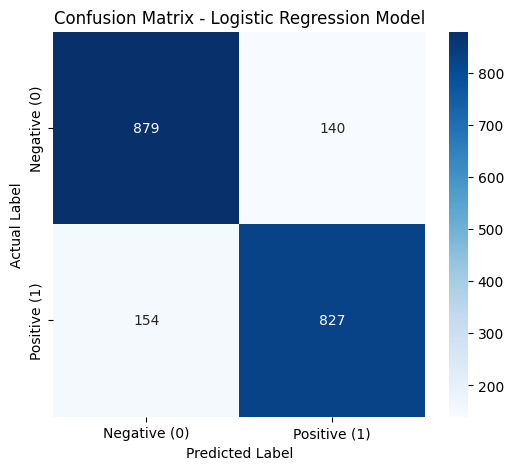


--- Detailed Classification Report (Logistic Regression) ---
              precision    recall  f1-score   support

    Negative       0.85      0.86      0.86      1019
    Positive       0.86      0.84      0.85       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000


--- Key Sentiment Indicator Words ---
Top 10 Positive Features: favorite, easy, amazing, wonderful, good, perfect, love, best, excellent, great
Top 10 Negative Features: boring, bad, worst, poor, disappointed, waste, disappointing, money, horrible, don


In [12]:
def evaluate_classifier(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
    }


results = [
    evaluate_classifier(y_test, preds_lr, "Logistic Regression"),
    evaluate_classifier(y_test, preds_svm, "Linear SVM"),
    evaluate_classifier(y_test, preds_nb, "Multinomial Naive Bayes"),
]

evaluation_summary = pd.DataFrame(results)
print("\n--- Model Evaluation Summary ---")
print(evaluation_summary.to_string(index=False))

# Confusion Matrix for Best Performing Model (Logistic Regression)
plt.figure(figsize=(6, 5))
cm_lr = confusion_matrix(y_test, preds_lr)
sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative (0)", "Positive (1)"],
    yticklabels=["Negative (0)", "Positive (1)"],
)
plt.title("Confusion Matrix - Logistic Regression Model")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

# Classification Report
print("\n--- Detailed Classification Report (Logistic Regression) ---")
print(
    classification_report(
        y_test, preds_lr, target_names=["Negative", "Positive"]
    )
)

# Top Positive & Negative Keywords Analysis[cite: 21]
feature_names = np.array(tfidf.get_feature_names_out())
coefs = model_lr.coef_[0]

top_positive_words = feature_names[np.argsort(coefs)[-10:]]
top_negative_words = feature_names[np.argsort(coefs)[:10]]

print("\n--- Key Sentiment Indicator Words ---")
print("Top 10 Positive Features:", ", ".join(top_positive_words))
print("Top 10 Negative Features:", ", ".join(top_negative_words))